In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import torch.utils.data as data
import random
import albumentations as A
import torchvision.transforms as T
import random
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes, make_grid
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from PIL import Image
from pycocotools.coco import COCO
%matplotlib inline

In [2]:
BASE_DATA_FOLDER = "./HRSID_JPG"
TRAIN_ANN_FILE = f"{BASE_DATA_FOLDER}/annotations/train2017.json"
TEST_ANN_FILE = f"{BASE_DATA_FOLDER}/annotations/test2017.json"
DATA_DIR = f"{BASE_DATA_FOLDER}/images"
NUM_SAMPLES = 10

In [3]:
class COCODetectionDataset(data.Dataset):
    """
    PyTorch dataset for COCO object detection.
    Loads RGB images but keeps only the first channel (since all channels are identical).
    Args:
        root (str): Root directory where images are stored.
        annFile (str): Path to COCO annotation JSON file.
        transform (callable, optional): Transform to apply to image and targets.
            Should return (image_tensor, target_dict). The image tensor must be
            of shape (C, H, W) with C=3 (after ToTensor). The first channel will
            be extracted automatically.
        filter_crowds (bool): If True, exclude crowd annotations.
        remove_empty (bool): If True, skip images with no annotations after filtering.
    """
    def __init__(self, root, annFile, transform=None, filter_crowds=False, remove_empty=False):
        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transform = transform
        self.filter_crowds = filter_crowds
        self.remove_empty = remove_empty

        if self.remove_empty or self.filter_crowds:
            self.ids = self._filter_images()

    def _filter_images(self):
        """Remove images that have no annotations after optional crowd filtering."""
        valid_ids = []
        for img_id in self.ids:
            ann_ids = self.coco.getAnnIds(imgIds=img_id)
            anns = self.coco.loadAnns(ann_ids)
            if self.filter_crowds:
                anns = [ann for ann in anns if ann.get('iscrowd', 0) == 0]
            if len(anns) > 0 or not self.remove_empty:
                valid_ids.append(img_id)
        return valid_ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        # Load image as RGB (3 channels)
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        image = np.array(Image.open(img_path).convert('RGB')) # always load as RGB
        # Load annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Filter out crowd annotations if required
        if self.filter_crowds:
            anns = [ann for ann in anns if ann.get('iscrowd', 0) == 0]

        # Get boxes and labels
        boxes = []
        labels = []
        area = []
        iscrowd = []
        for ann in anns:
            # Convert  [x, y, width, height] to [x1, y1, x2, y2] (torchvision detection format)
            boxes.append(box_convert(torch.as_tensor(ann["bbox"]), in_fmt="xywh", out_fmt="xyxy"))
            labels.append(ann['category_id'])
            area.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))
            
        # Apply user transforms (if any). They should return (image_tensor, target_dict)
        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes)
            image = transformed["image"] / 255.0
            boxes = transformed["bboxes"]
            if isinstance(image, np.ndarray):
                image = torch.from_numpy(image).permute(2, 0, 1).float()
        else:
            # Default: convert to tensor without any augmentations
            image = transforms.ToTensor()(image)  # shape (3, H, W)
        # Convert to tensors
        if len(boxes) == 0:
            target = {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,), dtype=torch.int64),
                'area': torch.zeros((0,), dtype=torch.float32),
                'iscrowd': torch.zeros((0,), dtype=torch.uint8),
                'image_id': torch.tensor([img_id], dtype=torch.int64)
            }
        else:
            boxes = [torch.as_tensor(b, dtype=torch.float32) for b in boxes]
            target = {
                'boxes': torch.stack(boxes),
                'labels': torch.tensor(labels, dtype=torch.int64),
                'area': torch.tensor(area, dtype=torch.float32),
                'iscrowd': torch.tensor(iscrowd, dtype=torch.uint8),
                'image_id': torch.tensor([img_id], dtype=torch.int64)
            }

        # Keep only the first channel (since all three are identical)
        image = image[:1]

        return image, target

def collate_fn(batch):
    """
    Custom collate function for detection data.
    Returns images as a list of tensors and targets as a list of dicts.
    """
    return tuple(zip(*batch))

def get_coco_dataloaders(root, annFile,
                         transform_train=None, transform_val=None,
                         batch_size=8, num_workers=0,
                         train_split=0.8, random_seed=42):
    """
    Create train and validation dataloaders with separate transforms.
    The dataset is split by image IDs before building the datasets,
    so each split can have its own augmentations.
    """
    # Load COCO to get all image IDs
    coco = COCO(annFile)
    all_ids = list(sorted(coco.imgs.keys()))

    # Shuffle and split IDs
    random.Random(random_seed).shuffle(all_ids)
    split_idx = int(train_split * len(all_ids))
    train_ids = all_ids[:split_idx]
    val_ids = all_ids[split_idx:]

    # Create dataset instances with their own transforms and filtered IDs
    train_dataset = COCODetectionDataset(root, annFile, transform=transform_train)
    train_dataset.ids = train_ids

    val_dataset = COCODetectionDataset(root, annFile, transform=transform_val)
    val_dataset.ids = val_ids

    print(f"Train images: {len(train_dataset)}, Val images: {len(val_dataset)}")

    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                   num_workers=num_workers, collate_fn=collate_fn, pin_memory=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, collate_fn=collate_fn, pin_memory=True)

    return train_loader, val_loader

In [4]:
train_transform = A.Compose([
    A.MultiplicativeNoise(),
    A.HorizontalFlip(), 
    A.VerticalFlip(),
    A.RandomRotate90(),
    A.pytorch.transforms.ToTensorV2()], 
    bbox_params=A.BboxParams(coord_format="pascal_voc")
    )

# Validation transforms (only ToTensor)
val_transform = A.Compose([
    A.pytorch.transforms.ToTensorV2(),
])

In [5]:
train_loader, val_loader = get_coco_dataloaders(DATA_DIR, TRAIN_ANN_FILE, train_split=0.9, transform_train=train_transform, transform_val=val_transform)

loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Train images: 3277, Val images: 365


torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0790) tensor(0.0552)


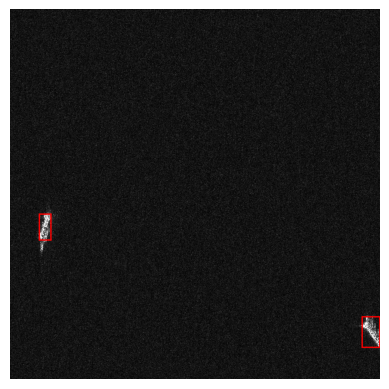

torch.Size([1, 800, 800]) tensor(0.) tensor(0.9725) tensor(0.1056) tensor(0.0947)


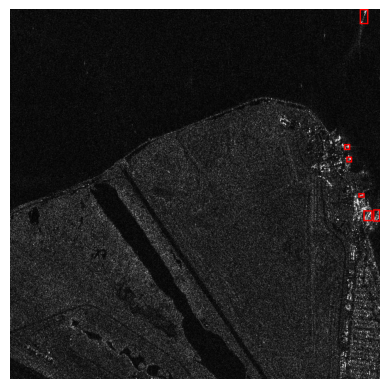

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0270) tensor(0.0183)


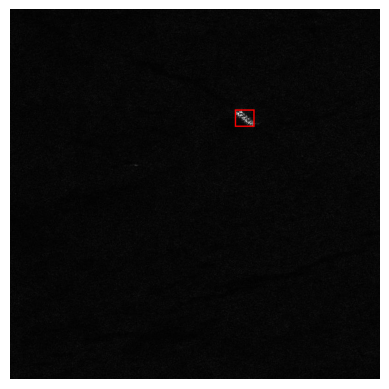

torch.Size([1, 800, 800]) tensor(0.) tensor(0.9059) tensor(0.0705) tensor(0.0544)


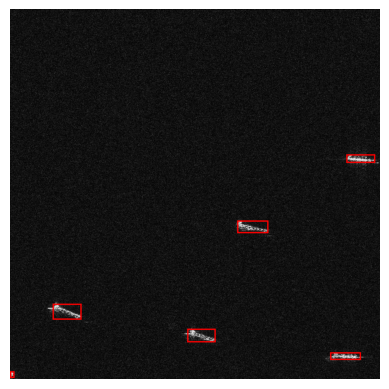

torch.Size([1, 800, 800]) tensor(0.) tensor(0.9725) tensor(0.0778) tensor(0.0617)


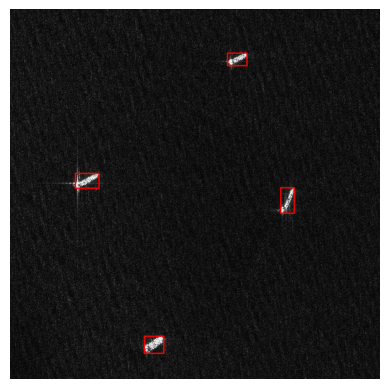

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0457) tensor(0.0331)


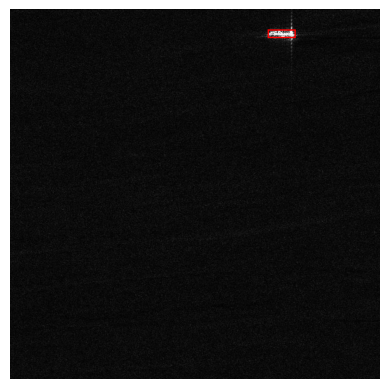

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0348) tensor(0.0225)


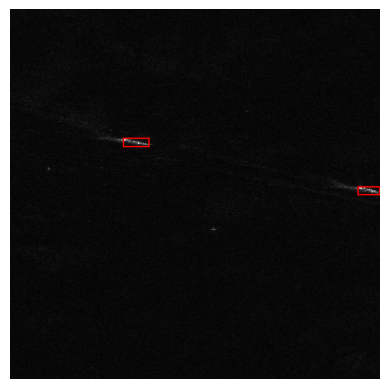

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0462) tensor(0.0249)


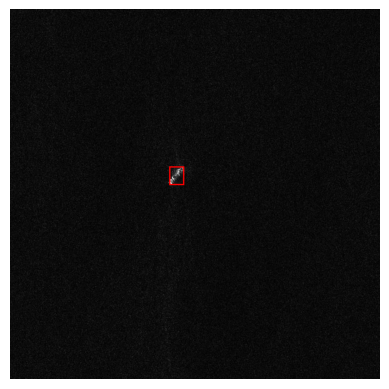

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0251) tensor(0.0176)


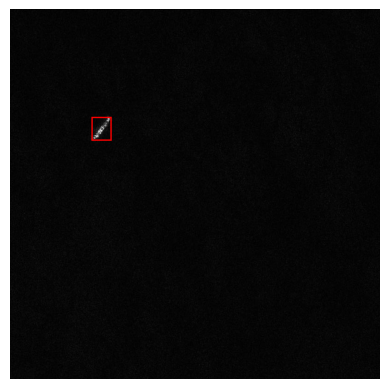

torch.Size([1, 800, 800]) tensor(0.) tensor(1.) tensor(0.0864) tensor(0.0519)


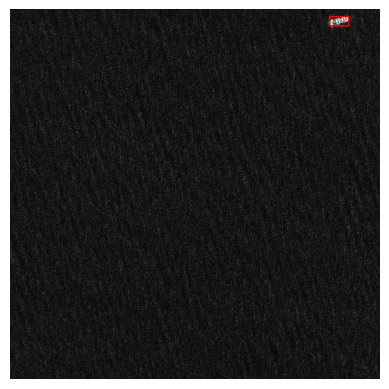

In [6]:
random.seed(44)
for _ in range(NUM_SAMPLES):
    iter_dloader = iter(train_loader)
    imgs, trgs = next(iter_dloader)
    img = imgs[0]
    trg = trgs[0]
    print(img.shape, img.min(), img.max(), img.mean(), img.std())
    img_with_bbox = draw_bounding_boxes(img, trg["boxes"], width = 3, colors = (255, 0, 0) )
    plt.imshow(img_with_bbox.numpy().transpose(2, 1, 0))
    plt.axis(False)
    plt.show()

In [7]:
pixel_sum, pixel_sq_sum, count = 0.0, 0.0, 0
for imgs, _ in train_loader:
    for img in imgs:
        img = img.float()
        pixel_sum    += img.mean().item()
        pixel_sq_sum += (img ** 2).mean().item()
        count        += 1

mean = pixel_sum / count
std  = (pixel_sq_sum / count - mean ** 2) ** 0.5
print(f"HRSID mean: {mean:.4f}, std: {std:.4f}")

HRSID mean: 0.0683, std: 0.0804


In [14]:
coco_dataset = COCO(TRAIN_ANN_FILE)
categories = coco_dataset.getCatIds()
num_classes = len(categories) + 1   # background is class 0
MAX_EPOCHS = 24
FREEZE_BACKBONE = False
VERSION = 1

loading annotations into memory...
Done (t=0.23s)
creating index...
index created!


In [2]:
class FasterRCNNLightning(L.pytorch.LightningModule):
    def __init__(self, model, lr=0.005, momentum=0.9, weight_decay=0.0005,
                 log_examples_freq=1, num_examples=12):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.log_examples_freq = log_examples_freq
        self.num_examples = num_examples

        # For validation metrics
        self.val_metric = MeanAveragePrecision()
        self.validation_step_outputs = []  # stores (preds, targets)

    def forward(self, images, targets=None):
        return self.model(images, targets)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        loss_dict = self.model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        for k, v in loss_dict.items():
            self.log(f'train_{k}', v, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_loss', losses, on_step=True, on_epoch=True, prog_bar=True)
        return losses
    
    def validation_step(self, batch, batch_idx):
        images, targets = batch
    
        # Get losses by temporarily switching to train mode
        self.model.train()
        with torch.no_grad():
            loss_dict = self.model(images, targets)
    
        # Get predictions in eval mode
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(images)
    
        for k, v in loss_dict.items():
            self.log(f'val_{k}', v, on_step=False, on_epoch=True)
        self.validation_step_outputs.append((outputs, targets))

        if batch_idx == 0 and self.current_epoch % self.log_examples_freq == 0:
            self._log_examples(images, targets, outputs)
        return outputs
        
    def on_validation_epoch_end(self):
        # Compute mAP from all stored predictions
        all_preds = [p for out, _ in self.validation_step_outputs for p in out]
        all_targets = [t for _, tgts in self.validation_step_outputs for t in tgts]
        self.val_metric.update(all_preds, all_targets)
        map_result = self.val_metric.compute()
        self.log('val_map', map_result['map'], on_epoch=True)
        self.val_metric.reset()
        self.validation_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = optim.SGD(self.model.parameters(), lr=self.lr,
                              momentum=self.momentum, weight_decay=self.weight_decay)
        scheduler = MultiStepLR(optimizer, milestones=[16, 22], gamma=0.1)
        return [optimizer], [scheduler]

    def _log_examples(self, images, targets, outputs):
        """Log a grid of images with ground truth (green) and predicted (red) boxes."""
        n = min(self.num_examples, len(images))
        imgs_gt, imgs_pred = [], []
        for i in range(n):
            img = images[i].cpu()                     # (1, H, W) in [0,1]
            # Convert to 3‑channel uint8 for drawing
            img_3ch = img.repeat(3, 1, 1) * 255
            img_3ch = img_3ch.byte()

            # Ground truth boxes
            gt_boxes = targets[i]['boxes'].cpu()
            img_with_gt = draw_bounding_boxes(img_3ch, gt_boxes, colors='green', width=2)

            # Predicted boxes (filter by confidence > 0.5)
            pred_boxes = outputs[i]['boxes'].cpu()
            pred_scores = outputs[i]['scores'].cpu()
            keep = pred_scores > 0.5
            pred_boxes = pred_boxes[keep]
            if len(pred_boxes) > 0:
                img_with_pred = draw_bounding_boxes(img_3ch, pred_boxes, colors='red', width=2)
            else:
                img_with_pred = img_3ch

            imgs_gt.append(img_with_gt)
            imgs_pred.append(img_with_pred)

        # Create a 2‑row grid: first row GT, second row predictions
        grid = torch.cat([torch.stack(imgs_gt), torch.stack(imgs_pred)], dim=0)  # (2*n, 3, H, W)
        grid_img = make_grid(grid, nrow=n)  # arrange in rows
        self.logger.experiment.add_image('examples', grid_img, global_step=self.current_epoch)

In [3]:
def get_faster_rcnn(num_classes, pretrained=True, freeze_backbone=True):
    if pretrained:
        model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    else:
        model = fasterrcnn_resnet50_fpn()
    
    model.transform.image_mean = [0.0682]
    model.transform.image_std = [0.0805]
    
    old_conv = model.backbone.body.conv1
    new_conv = nn.Conv2d(1, old_conv.out_channels,
                         kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride,
                         padding=old_conv.padding,
                         bias=old_conv.bias is not None)
    if pretrained:
        new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        if old_conv.bias is not None:
            new_conv.bias.data = old_conv.bias.data
    model.backbone.body.conv1 = new_conv
    
    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
        for param in model.backbone.body.conv1.parameters():
            param.requires_grad = True

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [16]:
torch.set_float32_matmul_precision('medium')
# ===== Model =====
faster_rcnn_imagenet = get_faster_rcnn(num_classes, freeze_backbone=FREEZE_BACKBONE)
model_lightning = FasterRCNNLightning(faster_rcnn_imagenet, lr=0.01)
logger = TensorBoardLogger("./logs/", f"faster_rcnn_{'freezed' if FREEZE_BACKBONE else 'full'}", version=VERSION)
checkpoint = ModelCheckpoint(monitor='val_map', mode='max', save_top_k=1)
# ===== Trainer =====
trainer = L.pytorch.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    callbacks=[checkpoint],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
)
trainer.fit(model_lightning, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: []

  | Name       | Type                 | Params | Mode 
------------------------------------------------------------
0 | model      | FasterRCNN           | 41.3 M | train
1 | val_metric | MeanAveragePrecision | 0      | train
------------------------------------------------------------
41.1 M    Trainable params
212 K     Non-trainable params
41.3 M    Total params
165.172   Total estimated model params size (MB)
190       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\lightning\pytorch\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. 

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=24` reached.


In [8]:
import timm
import torch
import torch.nn as nn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import BackboneWithFPN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import misc as misc_nn_ops
from torchvision.ops.feature_pyramid_network import LastLevelMaxPool
from torchgeo.models import ResNet50_Weights, resnet50

def get_faster_rcnn_sentinel1(num_classes, polarization='VV', freeze_backbone=True):
    """
    Faster R-CNN with ResNet-50 FPN backbone pretrained on Sentinel-1 GRD via SoftCon.

    Training on HRSID (uint8, 0-255):
        - Images are already in 0-255 range → normalize to [0, 1] by dividing by 255
        - model.transform will then apply (x - 0.5) / 0.5 (roughly, see below)

    Inference on real Copernicus S1:
        - Convert sigma0 linear → dB: 10 * log10(sigma0)
        - Apply softcon_to_uint8() to get 0-255 matching HRSID's distribution
        - Then same pipeline as training

    Args:
        num_classes:     number of classes including background
        polarization:    'VV' or 'VH'
        freeze_backbone: freeze backbone except conv1
    """
    assert polarization in SENTINEL1_BAND_INDEX

    band_idx = SENTINEL1_BAND_INDEX[polarization]

    # 1. Load SoftCon pretrained ResNet50 for Sentinel-1 GRD (2-channel: VV+VH)
    weights = ResNet50_Weights.SENTINEL1_GRD_SOFTCON
    backbone_timm = resnet50(weights=weights)  # timm model, in_chans=2

    # 2. Replace conv1: 2-channel → 1-channel by selecting the target polarization
    #    We SELECT rather than average — VV and VH have distinct learned filter responses
    old_conv = backbone_timm.conv1  # [64, 2, 7, 7]
    new_conv = nn.Conv2d(
        1, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None
    )
    new_conv.weight.data = old_conv.weight.data[:, band_idx:band_idx+1, :, :]
    if old_conv.bias is not None:
        new_conv.bias.data = old_conv.bias.data
    backbone_timm.conv1 = new_conv

    # 3. Wrap timm model into torchvision BackboneWithFPN
    backbone = BackboneWithFPN(
        backbone_timm,
        return_layers={'layer1': '0', 'layer2': '1', 'layer3': '2', 'layer4': '3'},
        in_channels_list=[256, 512, 1024, 2048],
        out_channels=256,
        extra_blocks=LastLevelMaxPool(),
    )

    # 4. Build Faster R-CNN
    model = FasterRCNN(backbone, num_classes=num_classes)

    # 5. Normalization:
    #    HRSID images are uint8 0-255, loaded and divided by 255 → [0, 1]
    #    SoftCon's 2-sigma clip for VV maps [-23.11, -2.07] dB → [0, 255] → /255 → [0, 1]
    #    So mean ≈ 0.5, std ≈ 0.2 in [0,1] space (approximation — compute from your data)
    #    Using 0.5/0.2 is a safe starting point; replace with computed HRSID stats
    model.transform.image_mean = [0.0682]
    model.transform.image_std  = [0.0805]

    # 6. Freeze backbone except conv1
    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
        for param in model.backbone.body.conv1.parameters():
            param.requires_grad = True

    # 7. Replace detection head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [13]:
torch.set_float32_matmul_precision('medium')
# ===== Model =====
faster_rcnn_sentinel = get_faster_rcnn_sentinel1(num_classes, freeze_backbone=FREEZE_BACKBONE)
model_lightning = FasterRCNNLightning(faster_rcnn_sentinel, lr=0.005)
logger = TensorBoardLogger("./logs/", f"faster_rcnn_sentinel_{'freezed' if FREEZE_BACKBONE else 'full'}", version=VERSION)
checkpoint = ModelCheckpoint(monitor='val_map', mode='max', save_top_k=1)
# ===== Trainer =====
trainer = L.pytorch.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    callbacks=[checkpoint],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
)
trainer.fit(model_lightning, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type                 | Params | Mode 
------------------------------------------------------------
0 | model      | FasterRCNN           | 41.3 M | train
1 | val_metric | MeanAveragePrecision | 0      | train
------------------------------------------------------------
41.3 M    Trainable params
0         Non-trainable params
41.3 M    Total params
165.384   Total estimated model params size (MB)
254       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=24` reached.


In [14]:
from torchgeo.models import ViTSmall16_Weights
import timm

def get_faster_rcnn_vitsmall(num_classes, freeze_backbone=True):
    from torchvision.models.detection import FasterRCNN
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.ops.feature_pyramid_network import LastLevelMaxPool, FeaturePyramidNetwork

    TARGET_SIZE = 800
    PATCH_SIZE  = 16
    OLD_GRID    = 14   # 224 // 16
    NEW_GRID    = TARGET_SIZE // PATCH_SIZE  # 50

    # 1. Load pretrained weights and fix patch_embed + pos_embed BEFORE creating model
    weights    = ViTSmall16_Weights.SENTINEL1_GRD_FGMAE
    state_dict = weights.get_state_dict(progress=True)

    # 2-channel → 1-channel patch embed by averaging
    key = 'patch_embed.proj.weight'
    state_dict[key] = state_dict[key].mean(dim=1, keepdim=True)

    # Interpolate pos_embed: [1, 197, 384] → [1, 2501, 384]
    pos_embed  = state_dict['pos_embed']          # [1, 197, 384]
    cls_token  = pos_embed[:, :1, :]              # [1, 1, 384]
    patch_pos  = pos_embed[:, 1:, :]              # [1, 196, 384]
    patch_pos  = patch_pos.reshape(1, OLD_GRID, OLD_GRID, -1).permute(0, 3, 1, 2).float()
    patch_pos  = torch.nn.functional.interpolate(
        patch_pos, size=(NEW_GRID, NEW_GRID), mode='bicubic', align_corners=False
    )
    patch_pos  = patch_pos.permute(0, 2, 3, 1).reshape(1, NEW_GRID * NEW_GRID, -1)
    state_dict['pos_embed'] = torch.cat([cls_token, patch_pos], dim=1)  # [1, 2501, 384]

    # 2. Create model at TARGET size with 1 channel — weights now match exactly
    vit = timm.create_model(
        'vit_small_patch16_224',
        pretrained=False,
        in_chans=1,
        img_size=TARGET_SIZE,  # 800 — matches interpolated pos_embed
        num_classes=0,
    )
    vit.load_state_dict(state_dict, strict=False)

    # 3. ViTDet backbone
    class ViTDetBackbone(nn.Module):
        def __init__(self, vit, out_channels=256):
            super().__init__()
            self.vit = vit
            embed_dim = vit.embed_dim  # 384
            self.fpn = FeaturePyramidNetwork(
                in_channels_list=[embed_dim, embed_dim, embed_dim, embed_dim],
                out_channels=out_channels,
                extra_blocks=LastLevelMaxPool()
            )
            self.out_channels = out_channels
            n = len(vit.blocks)
            self.tap_indices = [n//4, n//2, 3*n//4, n-1]

        def forward(self, x):
            B, C, H, W = x.shape
            x = self.vit.patch_embed(x)
            x = self.vit._pos_embed(x)
            x = self.vit.patch_drop(x)
            x = self.vit.norm_pre(x)

            h_feat = H // PATCH_SIZE
            w_feat = W // PATCH_SIZE

            tapped  = {}
            tap_map = {idx: i for i, idx in enumerate(self.tap_indices)}
            for i, block in enumerate(self.vit.blocks):
                x = block(x)
                if i in tap_map:
                    tokens = x[:, self.vit.num_prefix_tokens:]
                    feat   = tokens.permute(0, 2, 1).reshape(B, -1, h_feat, w_feat)
                    tapped[str(tap_map[i])] = feat
            return self.fpn(tapped)

    backbone = ViTDetBackbone(vit, out_channels=256)

    # 4. Build Faster R-CNN
    model = FasterRCNN(backbone, num_classes=num_classes)
    model.transform.image_mean = [0.0682]
    model.transform.image_std  = [0.0805]

    # 5. Freeze backbone except patch_embed and FPN
    if freeze_backbone:
        for param in backbone.vit.parameters():
            param.requires_grad = False
        for param in backbone.vit.patch_embed.parameters():
            param.requires_grad = True
        for param in backbone.fpn.parameters():
            param.requires_grad = True

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [15]:
torch.set_float32_matmul_precision('medium')
# ===== Model =====
faster_rcnn_vits = get_faster_rcnn_vitsmall(num_classes, freeze_backbone=FREEZE_BACKBONE)
model_lightning = FasterRCNNLightning(faster_rcnn_vits, lr=0.005)
logger = TensorBoardLogger("./logs/", f"faster_rcnn_sentinel_vits_{'freezed' if FREEZE_BACKBONE else 'full'}", version=VERSION)
checkpoint = ModelCheckpoint(monitor='val_map', mode='max', save_top_k=1)
# ===== Trainer =====
trainer = L.pytorch.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    callbacks=[checkpoint],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
)
trainer.fit(model_lightning, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type                 | Params | Mode 
------------------------------------------------------------
0 | model      | FasterRCNN           | 39.6 M | train
1 | val_metric | MeanAveragePrecision | 0      | train
------------------------------------------------------------
39.6 M    Trainable params
0         Non-trainable params
39.6 M    Total params
158.433   Total estimated model params size (MB)
317       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=24` reached.


In [16]:
# from torchgeo.models import Swin_V2_B_Weights
# from torchvision.models import swin_v2_b

# def get_faster_rcnn_swin(num_classes, freeze_backbone=True):
#     """
#     Faster R-CNN with Swin-V2-B backbone pretrained on Sentinel-1 via SATLAS.
#     Swin is hierarchical so it plugs into FPN naturally like ResNet.
#     Uses SENTINEL1_SI_SATLAS (single-image, most relevant for inference on individual scenes).
#     """
#     from torchvision.models.detection import FasterRCNN
#     from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
#     from torchvision.ops.feature_pyramid_network import LastLevelMaxPool, FeaturePyramidNetwork

#     # 1. Load Swin-V2-B with SATLAS S1 weights (2-channel input)
#     weights = Swin_V2_B_Weights.SENTINEL1_SI_SATLAS
#     swin = swin_v2_b(weights=None)

#     # Adapt first conv (PatchEmbed) from 3→1 channel
#     # Swin's patch embedding: features.0.0 is the first Conv2d
#     old_conv = swin.features[0][0]
#     new_conv = nn.Conv2d(
#         1, old_conv.out_channels,
#         kernel_size=old_conv.kernel_size,
#         stride=old_conv.stride,
#         padding=old_conv.padding,
#         bias=old_conv.bias is not None
#     )

#     # Load pretrained state dict and adapt
#     state_dict = weights.get_state_dict(progress=True)
#     # The SATLAS weights may have 2-channel patch embed — average to 1
#     patch_key = 'features.0.0.weight'
#     if patch_key in state_dict:
#         if state_dict[patch_key].shape[1] == 2:
#             state_dict[patch_key] = state_dict[patch_key].mean(dim=1, keepdim=True)
#         elif state_dict[patch_key].shape[1] == 3:
#             state_dict[patch_key] = state_dict[patch_key].mean(dim=1, keepdim=True)
#     new_conv.weight.data = state_dict[patch_key]
#     swin.features[0][0] = new_conv
#     swin.load_state_dict(state_dict, strict=False)

#     # 2. Wrap Swin into BackboneWithFPN
#     #    Swin-V2-B outputs at 4 stages: 128, 256, 512, 1024 channels
#     class SwinBackbone(nn.Module):
#         def __init__(self, swin, out_channels=256):
#             super().__init__()
#             # Swin stages interleaved with downsampling in features list
#             # features: [0]=PatchEmbed, [1]=stage1, [2]=downsample,
#             #           [3]=stage2, [4]=downsample, [5]=stage3, [6]=downsample, [7]=stage4
#             self.patch_embed = swin.features[0]
#             self.stage1 = swin.features[1]
#             self.down1  = swin.features[2]
#             self.stage2 = swin.features[3]
#             self.down2  = swin.features[4]
#             self.stage3 = swin.features[5]
#             self.down3  = swin.features[6]
#             self.stage4 = swin.features[7]
#             self.norm   = swin.norm

#             self.fpn = FeaturePyramidNetwork(
#                 in_channels_list=[128, 256, 512, 1024],
#                 out_channels=out_channels,
#                 extra_blocks=LastLevelMaxPool()
#             )
#             self.out_channels = out_channels

#         def forward(self, x):
#             x  = self.patch_embed(x)   # (B, H/4, W/4, 128)
#             x  = self.stage1(x);  c1 = x.permute(0,3,1,2)  # (B,128,H/4,W/4)
#             x  = self.down1(x)
#             x  = self.stage2(x);  c2 = x.permute(0,3,1,2)  # (B,256,H/8,W/8)
#             x  = self.down2(x)
#             x  = self.stage3(x);  c3 = x.permute(0,3,1,2)  # (B,512,H/16,W/16)
#             x  = self.down3(x)
#             x  = self.stage4(x);  c4 = x.permute(0,3,1,2)  # (B,1024,H/32,W/32)

#             return self.fpn({'0': c1, '1': c2, '2': c3, '3': c4})

#     backbone = SwinBackbone(swin, out_channels=256)

#     # 3. Build Faster R-CNN
#     model = FasterRCNN(backbone, num_classes=num_classes)
#     model.transform.image_mean = [0.0682]
#     model.transform.image_std  = [0.0805]

#     # 4. Freeze backbone stages, keep patch_embed and FPN trainable
#     if freeze_backbone:
#         for param in backbone.parameters():
#             param.requires_grad = False
#         for param in backbone.patch_embed.parameters():
#             param.requires_grad = True
#         for param in backbone.fpn.parameters():
#             param.requires_grad = True

#     in_features = model.roi_heads.box_predictor.cls_score.in_features
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
#     return model

In [17]:
# torch.set_float32_matmul_precision('medium')
# # ===== Model =====
# faster_rcnn_swin = get_faster_rcnn_swin(num_classes, freeze_backbone=FREEZE_BACKBONE)
# model_lightning = FasterRCNNLightning(faster_rcnn_swin, lr=0.005)
# logger = TensorBoardLogger("./logs/", "faster_rcnn_sentinel_vits")
# checkpoint = ModelCheckpoint(monitor='val_map', mode='max', save_top_k=1)
# # ===== Trainer =====
# trainer = L.pytorch.Trainer(
#     max_epochs=MAX_EPOCHS,
#     logger=logger,
#     callbacks=[checkpoint],
#     accelerator='gpu' if torch.cuda.is_available() else 'cpu',
#     devices=1,
# )
# trainer.fit(model_lightning, train_loader, val_loader)

In [7]:
import os
import json
import shutil
import random
from pathlib import Path
from ultralytics import YOLO
from torch.utils.tensorboard import SummaryWriter

# ============================================================
# Step 1: Convert HRSID COCO → YOLO format with 90/10 split
# ============================================================

def coco_to_yolo(ann_file, img_dir, output_dir, train_ratio=0.9, seed=42):
    """
    Convert COCO annotations to YOLO format and split into train/val.
    YOLO format: class cx cy w h (normalized 0-1)
    """
    output_dir = Path(output_dir)
    for split in ['train', 'val']:
        (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

    with open(ann_file) as f:
        coco = json.load(f)

    # Map image_id → image info
    img_map = {img['id']: img for img in coco['images']}

    # Map image_id → list of annotations
    ann_map = {}
    for ann in coco['annotations']:
        ann_map.setdefault(ann['image_id'], []).append(ann)

    # Shuffle and split image ids
    all_ids = list(img_map.keys())
    random.Random(seed).shuffle(all_ids)
    split_idx  = int(len(all_ids) * train_ratio)
    split_map  = {img_id: 'train' if i < split_idx else 'val'
                  for i, img_id in enumerate(all_ids)}

    print(f"Train: {split_idx}, Val: {len(all_ids) - split_idx}")

    for img_id, img_info in img_map.items():
        split  = split_map[img_id]
        W, H   = img_info['width'], img_info['height']
        fname  = img_info['file_name']
        stem   = Path(fname).stem

        # Copy image
        src = Path(img_dir) / fname
        dst = output_dir / 'images' / split / Path(fname).name
        if src.exists():
            shutil.copy2(src, dst)

        # Write label file
        anns  = ann_map.get(img_id, [])
        lines = []
        for ann in anns:
            if ann.get('iscrowd', 0):
                continue
            x, y, w, h = ann['bbox']  # COCO: x1 y1 w h
            cx = (x + w / 2) / W
            cy = (y + h / 2) / H
            nw = w / W
            nh = h / H
            # class 0 = ship (HRSID is single class)
            lines.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        label_path = output_dir / 'labels' / split / f"{stem}.txt"
        with open(label_path, 'w') as f:
            f.write('\n'.join(lines))

    # Write dataset yaml
    yaml_content = f"""path: {output_dir.absolute()}
train: images/train
val: images/val

nc: 1
names:
  0: ship
"""
    yaml_path = output_dir / 'hrsid.yaml'
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"Dataset ready at {output_dir}")
    print(f"YAML: {yaml_path}")
    return str(yaml_path)


# ============================================================
# Step 2: Train both models with TensorBoard logging
# ============================================================

def train_yolo26(
    yaml_path:   str,
    output_dir:  str  = 'runs/yolo26',
    epochs:      int  = 100,
    imgsz:       int  = 800,
    batch:       int  = 16,
    device:      str  = '0',   # '0' for GPU, 'cpu' for CPU
):
    models = {
        # 'yolo26s': YOLO('yolo26s.pt'),
        'yolo26m': YOLO('yolo26m.pt'),
    }

    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}")
        print(f"{'='*50}")

        model.train(
            data        = yaml_path,
            epochs      = epochs,
            imgsz       = imgsz,
            batch       = batch,
            device      = device,
            project     = output_dir,
            name        = name,
            # Single channel SAR images
            # YOLO expects 3-channel by default — handled below
            # channels    = 1,
            # Logging
            plots       = True,
            save        = True,
            save_period = 5,
            # Augmentation — conservative for SAR
            hsv_h       = 0.0,   # no hue shift (grayscale)
            hsv_s       = 0.0,   # no saturation (grayscale)
            hsv_v       = 0.2,   # slight brightness variation
            fliplr      = 0.5,   # horizontal flip
            flipud      = 0.5,   # vertical flip (ships can appear any orientation)
            mosaic      = 0.5,
            # Optimizer
            optimizer   = 'MuSGD',  # YOLO26's new optimizer
            lr0         = 0.01,
            # TensorBoard is enabled by default in ultralytics
            # logs go to output_dir/name/
        )

        print(f"\n{name} training complete.")
        print(f"Best weights: {output_dir}/{name}/weights/best.pt")

In [8]:
DEVICE     = '0'   # GPU; use 'cpu' if no GPU

# 1. Convert dataset
yaml_path = coco_to_yolo(TEST_ANN_FILE, DATA_DIR, DATA_DIR+"/yolo")

# 2. Train both models
train_yolo26(yaml_path=yaml_path, output_dir="./logs",  device=DEVICE, epochs=24)

Train: 1765, Val: 197
Dataset ready at HRSID_JPG\images\yolo
YAML: HRSID_JPG\images\yolo\hrsid.yaml

Training yolo26m
Ultralytics 8.4.14  Python-3.11.11 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=HRSID_JPG\images\yolo\hrsid.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=24, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=0.5, mul

# test

In [40]:
import numpy as np
import torch
import rasterio
import json
from torchvision.ops import nms
from rasterio.transform import from_bounds
from shapely.geometry import box, mapping
from shapely.geometry import Point

STATS = {
    'VV': {'mean': -12.59, 'std': 5.26},
    'VH': {'mean': -20.26, 'std': 5.91},
    'HH': {'mean': -12.59, 'std': 5.26},
    'HV': {'mean': -20.26, 'std': 5.91},
}

def preprocess_s1(image: np.ndarray, polarization: str, input_format: str) -> torch.Tensor:
    """Convert any S1 format to [0,1] tensor matching HRSID training distribution."""
    pol = polarization.upper()
    if input_format == 'byte':
        arr = image.astype(np.float32) / 255.0
    elif input_format == 'linear':
        arr = 10.0 * np.log10(np.clip(image.astype(np.float32), 1e-10, None))
        arr = _db_to_unit(arr, pol)
    elif input_format == 'db':
        arr = _db_to_unit(image.astype(np.float32), pol)
    else:
        raise ValueError(f"Unknown input_format: {input_format}. Use 'byte', 'linear', or 'db'")
    return torch.from_numpy(arr).unsqueeze(0)  # (1, H, W)

def _db_to_unit(image_db: np.ndarray, polarization: str) -> np.ndarray:
    mean    = STATS[polarization]['mean']
    std     = STATS[polarization]['std']
    min_val = mean - 2 * std
    max_val = mean + 2 * std
    return np.clip((image_db - min_val) / (max_val - min_val), 0.0, 1.0).astype(np.float32)

def score_to_confidence_bin(score: float) -> str:
    """Map score [0,1] to confidence bin string."""
    pct = int(score * 100)
    if pct < 10:
        return '<10'
    elif pct >= 100:
        return '90-100'
    else:
        low = (pct // 10) * 10
        return f'{low}-{low+10}'

def run_inference(
    image_path: str,
    model: torch.nn.Module,
    output_geojson: str,
    polarization: str   = 'VV',
    input_format: str   = 'byte',
    window_size: int    = 800,
    overlap_pct: float  = 0.25,
    score_thresh: float = 0.3,
    nms_iou: float      = 0.3,
    device: str         = 'cpu',
):
    device_obj = torch.device(device)
    model      = model.to(device_obj)
    model.eval()
    stride = int(window_size * (1 - overlap_pct))

    # 1. Load image metadata only — read patches on demand
    with rasterio.open(image_path) as src:
        transform = src.transform
        crs       = src.crs
        H, W      = src.height, src.width
        profile   = src.profile

    print(f"Scene size: {H}x{W}, window: {window_size}, stride: {stride}")

    y_starts = list(range(0, H - window_size + 1, stride))
    x_starts = list(range(0, W - window_size + 1, stride))
    if y_starts[-1] + window_size < H:
        y_starts.append(H - window_size)
    if x_starts[-1] + window_size < W:
        x_starts.append(W - window_size)

    total = len(y_starts) * len(x_starts)
    print(f"Processing {total} patches...")

    all_boxes, all_scores, all_labels = [], [], []

    # 2. Read and process one patch at a time — no full image in RAM
    with rasterio.open(image_path) as src:
        for yi, y in enumerate(y_starts):
            for xi, x in enumerate(x_starts):
                print(f"  Patch {yi*len(x_starts)+xi+1}/{total}", end='\r')

                # Read only this window from disk
                window  = rasterio.windows.Window(x, y, window_size, window_size)
                patch   = src.read(1, window=window).astype(np.float32)

                # Preprocess
                tensor  = preprocess_s1(patch, polarization, input_format)
                tensor  = tensor.unsqueeze(0).to(device_obj)

                with torch.no_grad():
                    output = model(tensor)[0]

                boxes  = output['boxes'].cpu()
                scores = output['scores'].cpu()
                labels = output['labels'].cpu()

                # Free immediately
                del tensor, output
                
                keep   = scores > score_thresh
                boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

                # Offset to full scene coordinates
                boxes[:, [0, 2]] += x
                boxes[:, [1, 3]] += y

                all_boxes.append(boxes)
                all_scores.append(scores)
                all_labels.append(labels)

                # Free patch from RAM
                del patch

    print(f"\nRunning global NMS...")

    if not any(len(b) > 0 for b in all_boxes):
        print("No detections found.")
        _write_geojson([], output_geojson, crs)
        return []

    all_boxes  = torch.cat(all_boxes)
    all_scores = torch.cat(all_scores)
    all_labels = torch.cat(all_labels)

    keep       = nms(all_boxes, all_scores, iou_threshold=nms_iou)
    all_boxes  = all_boxes[keep]
    all_scores = all_scores[keep]
    all_labels = all_labels[keep]

    print(f"Detections after NMS: {len(all_boxes)}")

    # 3. Build GeoJSON features
    features = []
    for i in range(len(all_boxes)):
        x1, y1, x2, y2 = all_boxes[i].tolist()
        score  = all_scores[i].item()
        label  = all_labels[i].item()
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

        lon, lat = rasterio.transform.xy(transform, cy, cx)

        features.append({
            'type': 'Feature',
            'geometry': {'type': 'Point', 'coordinates': [lon, lat]},
            'properties': {
                'score':          round(score, 4),
                'confidence_bin': score_to_confidence_bin(score),
                'label':          label,
                'pixel_x':        round(cx),
                'pixel_y':        round(cy),
                'box_width':      round(x2 - x1),
                'box_height':     round(y2 - y1),
            }
        })

    _write_geojson(features, output_geojson, crs)
    print(f"GeoJSON written to: {output_geojson}")
    # return features


def _write_geojson(features: list, path: str, crs=None):
    geojson = {
        'type': 'FeatureCollection',
        'features': features,
    }
    if crs is not None:
        geojson['crs'] = {
            'type': 'name',
            'properties': {'name': crs.to_string()}
        }
    with open(path, 'w') as f:
        json.dump(geojson, f, indent=2)

In [12]:
EW_1_DAT="./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data"
EW_2_DAT="./S1C_EW_GRDM_1SDH_20260222T034030_20260222T034130_006463_00D051_46C6_Cal_ML_TC.data"
IV_1_DAT="./S1A_IW_GRDH_1SDV_20260221T150954_20260221T151019_063319_07F3A8_D6E7_Cal_ML_TC.data"
IV_2_DAT="./S1C_IW_GRDH_1SDV_20260221T155141_20260221T155206_006456_00D00E_BCA0_Cal_ML_TC.data"

In [7]:
lightning_model = FasterRCNNLightning.load_from_checkpoint(
    './logs/faster_rcnn_full/version_0/checkpoints/epoch=17-step=7380.ckpt',
    model=get_faster_rcnn(num_classes=2, freeze_backbone=False, pretrained=False)
)
model = lightning_model.model

In [8]:
torch.save(model.state_dict(), 'fasterrcnn_weights.pth')

In [29]:
# Run inference
run_inference(
    image_path    = EW_1_DAT+"/hh_dat.tif",
    model         = model,
    output_geojson= EW_1_DAT+"/hh_dat.geojson",
    polarization  = 'HH',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12739x24074, window: 800, stride: 600
Processing 840 patches...
  Patch 840/840
Done. Running global NMS...
Detections after NMS: 118
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hh_dat.geojson


In [31]:
# Run inference
run_inference(
    image_path    = EW_1_DAT+"/hh_img.tif",
    model         = model,
    output_geojson= EW_1_DAT+"/hh_img.geojson",
    polarization  = 'HH',
    input_format  = 'byte',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12739x24074, window: 800, stride: 600
Processing 840 patches...
  Patch 840/840
Done. Running global NMS...
Detections after NMS: 50
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hh_img.geojson


In [33]:
# Run inference
run_inference(
    image_path    = EW_1_DAT+"/hv_dat.tif",
    model         = model,
    output_geojson= EW_1_DAT+"/hv_dat.geojson",
    polarization  = 'HV',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12739x24074, window: 800, stride: 600
Processing 840 patches...
  Patch 840/840
Done. Running global NMS...
Detections after NMS: 188
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hv_dat.geojson


In [36]:
# Run inference
run_inference(
    image_path    = EW_2_DAT+"/hv_img.tif",
    model         = model,
    output_geojson= EW_2_DAT+"/hv_img.geojson",
    polarization  = 'HV',
    input_format  = 'byte',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12358x36790, window: 800, stride: 600
Processing 1281 patches...
  Patch 1281/1281
Done. Running global NMS...
Detections after NMS: 47
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260222T034030_20260222T034130_006463_00D051_46C6_Cal_ML_TC.data/hv_img.geojson


In [37]:
# Run inference
run_inference(
    image_path    = EW_2_DAT+"/hv_dat.tif",
    model         = model,
    output_geojson= EW_2_DAT+"/hv_dat.geojson",
    polarization  = 'HV',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12358x36790, window: 800, stride: 600
Processing 1281 patches...
  Patch 1281/1281
Done. Running global NMS...
Detections after NMS: 16
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260222T034030_20260222T034130_006463_00D051_46C6_Cal_ML_TC.data/hv_dat.geojson


In [38]:
# Run inference
run_inference(
    image_path    = EW_2_DAT+"/hh_dat.tif",
    model         = model,
    output_geojson= EW_2_DAT+"/hh_dat.geojson",
    polarization  = 'HH',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 12358x36790, window: 800, stride: 600
Processing 1281 patches...
  Patch 1281/1281
Done. Running global NMS...
Detections after NMS: 34
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260222T034030_20260222T034130_006463_00D051_46C6_Cal_ML_TC.data/hh_dat.geojson


In [43]:
# Run inference
run_inference(
    image_path    = IV_1_DAT+"/vv_dat.tif",
    model         = model,
    output_geojson= IV_1_DAT+"/vv_dat.geojson",
    polarization  = 'VV',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene size: 21906x78605, window: 800, stride: 600
Processing 4847 patches...
  Patch 4847/4847
Running global NMS...
Detections after NMS: 245
GeoJSON written to: ./S1A_IW_GRDH_1SDV_20260221T150954_20260221T151019_063319_07F3A8_D6E7_Cal_ML_TC.data/vv_dat.geojson


In [18]:
from ultralytics import YOLO
import rasterio
import numpy as np
import torch
import json
from pathlib import Path


STATS = {
    'VV': {'mean': -12.59, 'std': 5.26},
    'VH': {'mean': -20.26, 'std': 5.91},
    'HH': {'mean': -12.59, 'std': 5.26},
    'HV': {'mean': -20.26, 'std': 5.91},
}

def preprocess_s1(image: np.ndarray, polarization: str, input_format: str) -> np.ndarray:
    """
    Convert any S1 format to uint8 [0-255] numpy array for YOLO.
    YOLO expects HWC uint8 — no tensor needed.
    """
    pol = polarization.upper()

    if input_format == 'byte':
        arr = image.astype(np.float32)  # already 0-255

    elif input_format == 'linear':
        arr = np.log1p(image.astype(np.float32))
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-10) * 255.0

    elif input_format == 'db':
        arr = image.astype(np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-10) * 255.0

    else:
        raise ValueError(f"Unknown input_format: {input_format}. Use 'byte', 'linear', or 'db'")

    # YOLO expects HWC uint8 3-channel — replicate single channel to 3
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    arr = np.stack([arr, arr, arr], axis=-1)  # (H, W, 3)
    return arr


def score_to_confidence_bin(score: float) -> str:
    pct = int(score * 100)
    if pct < 10:
        return '<10'
    elif pct >= 100:
        return '90-100'
    low = (pct // 10) * 10
    return f'{low}-{low+10}'


def run_yolo_inference(
    image_path:     str,
    model_path:     str,
    output_geojson: str,
    polarization:   str   = 'VV',
    input_format:   str   = 'byte',
    window_size:    int   = 800,
    overlap_pct:    float = 0.25,
    score_thresh:   float = 0.3,
    nms_iou:        float = 0.3,
    device:         str   = 'cpu',
):
    """
    Run YOLO26 ship detection on a full Sentinel-1 scene.

    Args:
        image_path:     path to GeoTIFF (single band)
        model_path:     path to best.pt from YOLO training
        output_geojson: path to write GeoJSON results
        polarization:   VV / VH / HH / HV
        input_format:   'byte', 'db', or 'linear'
        window_size:    sliding window size in pixels
        overlap_pct:    overlap between patches (0.25 = 25%)
        score_thresh:   minimum confidence threshold
        nms_iou:        IoU threshold for global NMS
        device:         'cpu' or '0' (GPU)
    """
    stride = int(window_size * (1 - overlap_pct))

    # 1. Load YOLO model
    model = YOLO(model_path)
    model.to(device)

    # 2. Load scene metadata
    with rasterio.open(image_path) as src:
        transform = src.transform
        crs       = src.crs
        H, W      = src.height, src.width

    print(f"Scene: {H}x{W} | window: {window_size} | stride: {stride}")

    # Compute patch positions
    y_starts = list(range(0, H - window_size + 1, stride))
    x_starts = list(range(0, W - window_size + 1, stride))
    if not y_starts or y_starts[-1] + window_size < H:
        y_starts.append(max(0, H - window_size))
    if not x_starts or x_starts[-1] + window_size < W:
        x_starts.append(max(0, W - window_size))

    total = len(y_starts) * len(x_starts)
    print(f"Processing {total} patches...")

    all_boxes, all_scores, all_labels = [], [], []

    # 3. Sliding window — read patches on demand (no full image in RAM)
    with rasterio.open(image_path) as src:
        for yi, y in enumerate(y_starts):
            for xi, x in enumerate(x_starts):
                print(f"  Patch {yi*len(x_starts)+xi+1}/{total}", end='\r')

                window = rasterio.windows.Window(x, y, window_size, window_size)
                patch  = src.read(1, window=window).astype(np.float32)

                # Preprocess to uint8 HWC
                patch_rgb = preprocess_s1(patch, polarization, input_format)
                del patch

                # YOLO inference — pass numpy array directly
                results = model.predict(
                    patch_rgb.copy(),
                    conf      = score_thresh,
                    iou       = nms_iou,
                    imgsz     = window_size,
                    device    = device,
                    verbose   = False,
                )
                del patch_rgb

                # Extract boxes
                result = results[0]
                if result.boxes is None or len(result.boxes) == 0:
                    continue

                boxes  = result.boxes.xyxy.cpu().clone()    # (N, 4) x1y1x2y2
                scores = result.boxes.conf.cpu().clone()    # (N,)
                labels = result.boxes.cls.cpu().int().clone()  # (N,)

                # Offset to full scene coordinates
                boxes[:, [0, 2]] += x
                boxes[:, [1, 3]] += y

                all_boxes.append(boxes)
                all_scores.append(scores)
                all_labels.append(labels)

    print(f"\nRunning global NMS...")

    if not all_boxes:
        print("No detections found.")
        _write_geojson([], output_geojson, crs)
        return []

    all_boxes  = torch.cat(all_boxes)
    all_scores = torch.cat(all_scores)
    all_labels = torch.cat(all_labels)

    # Global NMS across overlapping patches
    from torchvision.ops import nms
    keep       = nms(all_boxes.float(), all_scores.float(), iou_threshold=nms_iou)
    all_boxes  = all_boxes[keep]
    all_scores = all_scores[keep]
    all_labels = all_labels[keep]

    print(f"Detections after NMS: {len(all_boxes)}")

    # 4. Build GeoJSON point features
    features = []
    for i in range(len(all_boxes)):
        x1, y1, x2, y2 = all_boxes[i].tolist()
        score  = all_scores[i].item()
        label  = int(all_labels[i].item())
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

        lon, lat = rasterio.transform.xy(transform, cy, cx)

        features.append({
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            },
            'properties': {
                'score':          round(score, 4),
                'confidence_bin': score_to_confidence_bin(score),
                'label':          label,
                'class_name':     model.names[label],
                'pixel_x':        round(cx),
                'pixel_y':        round(cy),
                'box_width':      round(x2 - x1),
                'box_height':     round(y2 - y1),
            }
        })

    _write_geojson(features, output_geojson, crs)
    print(f"GeoJSON written to: {output_geojson}")
    # return features


def _write_geojson(features: list, path: str, crs=None):
    geojson = {
        'type': 'FeatureCollection',
        'features': features,
    }
    if crs is not None:
        geojson['crs'] = {
            'type': 'name',
            'properties': {'name': crs.to_string()}
        }
    with open(path, 'w') as f:
        json.dump(geojson, f, indent=2)
    print(f"Saved {len(features)} detections → {path}")

In [13]:
from ultralytics import YOLO
model = YOLO("./runs/detect/logs/yolo26s4/weights/best.pt")
model.export(format='onnx', imgsz=800, simplify=True)

Ultralytics 8.4.14  Python-3.11.11 torch-2.10.0+cu128 CPU (AMD Ryzen 5 7500F 6-Core Processor)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from 'runs\detect\logs\yolo26s4\weights\best.pt' with input shape (1, 3, 800, 800) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 4.2 MB/s eta 0:00:04
   ------- -------------------------------- 2.9/16.4 MB 9.3 MB/s eta 0:00:02
   ------------ --------------------------- 5.2/16.4 MB 10.3 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/16.4 MB 10.8 MB/s eta 0:00:01
   ------------------------- -------------- 10.5/16.4 MB 11.1 MB/s eta 0:00:01
   ------------------------------- -------- 12.8/16.4 MB 11.2 MB/s eta 0:00

C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(
C:\Users\po4e4\anaconda3\envs\jupyterlab\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success  42.8s, saved as 'runs\detect\logs\yolo26s4\weights\best.onnx' (36.5 MB)

Export complete (43.3s)
Results saved to C:\Users\po4e4\Downloads\hrsid\runs\detect\logs\yolo26s4\weights
Predict:         yolo predict task=detect model=runs\detect\logs\yolo26s4\weights\best.onnx imgsz=800 
Validate:        yolo val task=detect model=runs\detect\logs\yolo26s4\weights\best.onnx imgsz=800 data=HRSID_JPG\images\yolo\hrsid.yaml  
Visualize:       https://netron.app


'runs\\detect\\logs\\yolo26s4\\weights\\best.onnx'

In [19]:
# Run inference
run_yolo_inference(
    image_path    = EW_1_DAT+"/hh_dat.tif",
    model_path     = './runs/detect/logs/yolo26s4/weights/best.pt',
    output_geojson= EW_1_DAT+"/hh_dat.geojson",
    polarization  = 'HH',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cpu' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene: 12739x24074 | window: 800 | stride: 600
Processing 840 patches...
  Patch 840/840
Running global NMS...
Detections after NMS: 473
Saved 473 detections → ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hh_dat.geojson
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hh_dat.geojson


In [20]:
# Run inference
run_yolo_inference(
    image_path    = EW_1_DAT+"/hv_dat.tif",
    model_path     = './runs/detect/logs/yolo26s4/weights/best.pt',
    output_geojson= EW_1_DAT+"/hv_dat.geojson",
    polarization  = 'HV',
    input_format  = 'linear',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene: 12739x24074 | window: 800 | stride: 600
Processing 840 patches...
  Patch 840/840
Running global NMS...
Detections after NMS: 330
Saved 330 detections → ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hv_dat.geojson
GeoJSON written to: ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hv_dat.geojson


In [21]:
# Run inference
run_yolo_inference(
    image_path    = EW_1_DAT+"/hv_img.tif",
    model_path     = './runs/detect/logs/yolo26s4/weights/best.pt',
    output_geojson= EW_1_DAT+"/hv_dat.geojson",
    polarization  = 'HV',
    input_format  = 'byte',       # or 'db' or 'linear'
    window_size   = 800,
    overlap_pct   = 0.25,         # 25% overlap
    nms_iou       = 0.3,
    score_thresh  = 0.3,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',        # or 'cuda'
)

Scene: 12739x24074 | window: 800 | stride: 600
Processing 840 patches...
  Patch 840/840
Running global NMS...
No detections found.
Saved 0 detections → ./S1C_EW_GRDM_1SDH_20260221T155513_20260221T155617_006456_00D00F_B9A6_Cal_ML_TC.data/hv_dat.geojson


[]